# Particle in a Box and Molecular Conjugation
In this notebook, we will develop and explore a simple quantum mechanical model used to describe electrons confined within molecules. Rather than starting from experimental measurements, we will begin with physical principles, construct a mathematical model, and translate that model into code to generate predictions. The system we study (a particle confined to a one-dimensional box) is one of the simplest quantum models, yet it captures essential features of real molecular systems, such as discrete energy levels and size-dependent optical properties. By implementing this model computationally, analyzing its predictions, and comparing them to more realistic quantum chemical calculations, you will investigate both the power and the limitations of theoretical models in chemistry. Throughout this notebook, the emphasis is on connecting equations, code, and physical interpretation so that each numerical result can be understood as a statement about molecular behavior.

---

**Chemistry Learning Objectives:**
 - C4.1: Explain how boundary conditions lead to quantized energies.
 - C4.2: Relate conjugation length to absorption wavelength.
 - C4.3: Identify limitations of simple quantum models.

---

**Programming Learning Objectives**
 - P4.1: Distinguish lists vs arrays vs strings and choose correctly.
 - P4.2: Use boolean masks for data selection.
 - P4.3: Write reusable functions with return values.
 - P4.4: Translate equations into code.

---

**Table of Contnents**

<br></br>

## Part 1 — Programming Foundations for Scientific Computing

Before we start building the particle-in-a-box model, we need a few programming tools that will appear repeatedly throughout this notebook. The goal of this section is not to memorize syntax, but to understand how Python represents information, and how those representations affect scientific calculations.

When you write code for chemistry, you are almost always working with one of the following kinds of objects.

### Lists, NumPy arrays, strings, and booleans

A **Python list** is a container. It is designed to hold a sequence of items, and it does not automatically behave like a mathematical object. Lists are useful for storing things, but they are not ideal for numerical computation.

A **NumPy array** is a numerical object. It represents a vector of numbers, and operations on arrays are interpreted as mathematical operations applied to every entry. Arrays are the standard tool for scientific computing in Python.

A **string** is text. Strings are used for labels, filenames, and messages. A string may look like a variable name, but it is not a variable. The string `"n"` is just the character `n`, not the value stored in the variable `n`.

A **boolean** is either `True` or `False`. In scientific computing, booleans often appear as **masks**, which are arrays of `True` and `False` values used to select certain parts of data. Masks are essential when you want to isolate a region of a spectrum or restrict a function to a physically meaningful domain.

### Variables and names

A **variable** is a name that stores a value. For example, if you write `n = 3`, then the variable `n` stores the number `3`. The quotation marks matter: `"n"` is text, while `n` is the variable holding a numerical value.

### Functions and return values

A **function** packages a calculation into a reusable tool. Most functions in scientific work should **return** values instead of only printing them. Printing shows information to a human, but returning makes the output available for later computation. If a function returns a value, you can use that output in another calculation, store it in a variable, plot it, or test it.

In the exercises below, you will practice these ideas in small examples. These skills are not separate from the chemistry. They are the tools that will let you build and analyze the particle-in-a-box model efficiently and correctly.

---

### Coding Activity 1
`15 points`

- P4.1: Distinguish lists vs arrays and choose correctly.

In scientific programming, understanding **what type of object an operation produces** is just as important as understanding the numerical result. Many bugs occur not because the math is wrong, but because the object type is not what you expected.

For each example below:

1. Read the operation after the `lambda` keyword.
2. Predict the **type of the result**.
3. Enter your answer, possible choices are:

    - `list`
    - `ndarray`
    - `int`
    - `float`
    - `str`

Only after you enter a guess will the code execute and reveal the result.

This exercise is about reasoning, not speed. If your guess is incorrect, read the explanation and try to understand why.

In [2]:
from helper import check_guess
guess = input("Type your guess for the output type: ")

check_guess(
    lambda: [1,2,3] * 2,
    guess
)

Type your guess for the output type:  list


Correct prediction.

Result of operation:
[1, 2, 3, 1, 2, 3]


In [4]:
import numpy as np
guess = input("Type your guess for the output type: ")

check_guess(
    lambda: np.array([1,2,3]) * 2,
    guess
)

Type your guess for the output type:  ndarray


Correct prediction.

Result of operation:
[2 4 6]


In [5]:
guess = input("Type your guess for the output type: ")

check_guess(
    lambda: np.array([1,2,3]) + [1,2,3],
    guess
)

Type your guess for the output type:  ndarray


Correct prediction.

Result of operation:
[2 4 6]


In [6]:
guess = input("Type your guess for the output type: ")

check_guess(
    lambda: "3" * 2,
    guess
)

Type your guess for the output type:  str


Correct prediction.

Result of operation:
33


In [7]:
guess = input("Type your guess for the output type: ")

check_guess(
    lambda: 4 * 2,
    guess
)


Type your guess for the output type:  int


Correct prediction.

Result of operation:
8


### Question 1
`5 points` 

 - P4.1: Distinguish lists vs arrays and choose correctly.

Why must numerical physics calculations use arrays rather than lists?

---

*Your answer here (`double click me!`):*

<br></br>

## Part 1 - Solving the Schrodinger Equation
For a quantum particle, the time-independent Schrodinger equation gives us the allowed energy levels of a particle.
$$
\hat{H} \psi{}(x) = -\frac{\hbar{}^2}{2m}\frac{d^2}{dx^2}\psi{}(x) + V(x)\psi{}(x)
$$
Where V(x) is the potential energy as a function of x.  
For a wavefunction to have a clearly defined energy, it must satisfy:
$$
\hat{H}\psi = E \psi
$$
Where $E$ is constant. In these special cases, we say that $\psi$ is an ___eigenfunction___ of the energy operator $\hat{H}$, and the observed energy $E$ is an ___eigenvalue___. 

To demonstrate how this gives rise to quantization, let's consider a particle confined within a one-dimensional box of length L, where the potential is defined as:
$$ V(x) =
\begin{cases} 
0, & 0 \leq x \leq L \\
\infty, & \text{otherwise}
\end{cases} $$
Within the region where $V(x) = 0$, the Schrodinger equation simplifies to:

$$-\frac{\hbar{}^2}{2m}\frac{d^2}{dx^2}\psi{}(x) = E \psi (x)$$

With this equation, we have three constraints which allow us to determine the allowable wavefunctions:
1. __Boundary conditions__: The wavefunction must be zero where the potential is infinite ($x < 0$ and $x > L$). 
2. __Continuity__: The wavefunction must be continuous.
3. __Eigenfunction__: The wavefunction must be proportional to its second derivative.

These conditions lead us to a discrete set of wavefunctions with quantized energy levels.

---

### Coding Activity 2
`10 points`

Write a function which will take in an array `x` and return a boolean mask where $0 \leq$ `x` $ \leq 4$. Pass the name of this function into interactive_pib_plot

In [3]:
%matplotlib widget 
from helper import interactive_pib_plot

### Question 2
`10 points + 5 bonus`

 - C4.1: Explain how boundary conditions lead to quantized energies.


a)  What values of k gave a wavefunction which satisfies the boundary condition of the particle in a box?
b) What relation do these values have to the length? Write a formula which relates these values to the value $\pi$, the length of the box, L, and the harmonic number, n.
c) (Bonus) What is the significance of the functions of the type $e^{ikx}$ shown in the plot?

---

*Your answer here (`double click me!`):*

<br></br>

# Part 3 Computational Experiment

In the particle-in-a-box model, an electron is confined to a finite region of space, and the allowed quantum states are determined by the Schrödinger equation together with boundary conditions. In lecture, you may have seen that this problem can be solved exactly, giving clean formulas for the allowed wavefunctions and energies. Most real chemical systems, however, do **not** admit closed-form solutions. For real molecules, potentials are complicated, electrons interact, and analytic expressions are rarely obtainable. In practice, chemists often rely on numerical methods to discover physically meaningful solutions rather than writing them down algebraically.

To see how this works in a controlled setting, we will approach the particle-in-a-box problem from a computational perspective. The key physical idea is the relationship between **kinetic energy and curvature**. In quantum mechanics, the kinetic energy operator is proportional to the second derivative of the wavefunction,
$$
\hat{T} \propto -\frac{d^2}{dx^2}.
$$
This means that wavefunctions that bend sharply (large curvature) correspond to higher kinetic energy, while smoother functions correspond to lower kinetic energy. Physically, the ground state of a confined particle must therefore be the smoothest function that satisfies the boundary conditions
$$
\psi(0)=\psi(L)=0.
$$

We can turn this physical idea into a numerical experiment. Instead of solving the differential equation directly, we define a quantity that measures how “energetically costly” a candidate wavefunction is. One useful choice is the Rayleigh quotient,
$$
R[\psi] = \frac{\int_0^L |\psi'(x)|^2 dx}{\int_0^L |\psi(x)|^2 dx}.
$$
The numerator measures how rapidly the function changes — in other words, how much curvature it has — while the denominator normalizes the function so that we compare only shapes, not sizes. Minimizing $R[\psi]$ is therefore equivalent to asking:

> Among all functions that satisfy the boundary conditions, which one has the lowest kinetic energy?

Rather than solving an equation analytically, we will supply a **trial function** and allow a numerical algorithm to reduce its curvature step by step until it reaches a stable shape. The result is the lowest-energy wavefunction supported by the box. In this sense, the computer acts as an experimental instrument: we prepare an initial “sample,” let a procedure act on it, and observe the outcome.

This approach closely mirrors how experimental chemistry works. In a wet lab, we often do not know the final result in advance. Instead, we prepare a system, run a procedure, and observe what state it settles into. Here, our “procedure” is a minimization algorithm, and our “measurement” is the final wavefunction. Just as physical systems naturally evolve toward lower energy states, our numerical system relaxes toward the lowest-curvature, lowest-energy solution allowed by the constraints.

By carrying out this computational experiment, you will see that quantized states do not need to be assumed or memorized — they can emerge naturally from the principle of energy minimization. This is the same philosophy that underlies many modern computational chemistry methods: when exact solutions are unavailable, we construct an energy functional and let numerical methods discover the physically allowed states for us.

---

# Coding Activity 3
`20 points`

 - C4.1: Explain how boundary conditions lead to quantized energies.
 - P4.3: Write reusable functions with return values.

1. **Construct trial functions**  
   Write code to generate at least three different initial guesses for $$\phi(x)$$ that are *not* sine waves but satisfy the boundary conditions $$\phi(0)=\phi(L)=0$$ (the minimizer defaults to $L = 1$, which may make your function simpler, but feel free to pass in any value of $L$ to `run_rayleigh_from_initial_guess`). Examples might include:
   - a Gaussian bump multiplied by $$x(L-x)$$,  
   - a low-order polynomial such as $$x(L-x)$$,  
   - a triangular “hat” function that vanishes at the boundaries.  

2. **Run the minimization**  
   For each initial guess, apply the numerical procedure that minimizes the Rayleigh quotient. Record: 
   - the final shape of $\phi(x)$ and  
   - the value of $R[\phi]$.  

3. **Compare to the analytic solution**  
   Plot the numerical ground state alongside the exact lowest mode, $$\sin(\pi x/L)$$ plots should include titles, a legend, and x and y axis labels. When two plots are very similar, try making one a dashed line for redability (check [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) for plotting help). Compute the overlap between your numerical result and the analytic solution to show they agree. For our purposes we can do a simple Riemann integral: $$ \int \psi \phi dx \approx \sum \psi_i \phi_i \Delta x.$$ Write a function to compute these integrals, and record the normalized overlap given by $$ \frac{\langle \psi \vert \phi \rangle}{\sqrt{\langle \psi \vert \psi \rangle \langle \phi \vert \phi \rangle}}  $$   

In [ ]:
from helper import run_rayleigh_from_initial_guess

# Here is the Gaussian bump as an example 
def gaussian_bump(x, center=0.5, width=0.1):
    phi0 = np.exp(-((x - center)**2) / (width**2))

    # enforce Dirichlet boundaries
    phi0[0] = 0.0
    phi0[-1] = 0.0

    return phi0

# This call will minmize the kinetic energy starting from your inital guess
x, phi_star, R_star = run_rayleigh_from_initial_guess(gaussian_bump)
print(f"Rayleigh quotient of Gaussian bump: {R_star}")

### Interpreting the Result

No matter which initial guess you supplied, the minimization procedure always converged to the same final function. This is not an accident, and it is not a property of the algorithm. It is a consequence of physics.

The quantity we minimized measures curvature, which is directly related to kinetic energy. Any trial function with sharp bends has high kinetic energy, so the numerical procedure smooths those bends out. Eventually, the system reaches the function that has the smallest possible curvature while still satisfying the boundary conditions. That function is the lowest-energy state of the system.

This is a general physical principle: **the ground state is the lowest-energy configuration compatible with the constraints.** The numerical method did not “know” the analytic answer in advance. It only followed the rule of decreasing energy, and the correct wavefunction emerged automatically.

> **Caveat — If Your Result Looked Different**
>
> If your minimization did *not* converge to the expected smooth ground-state shape, that does not necessarily mean your code is wrong. Numerical minimization methods such as gradient descent do not magically jump to the lowest-energy state; instead, they move step by step in whatever direction most decreases the objective function. Because of this, they can sometimes get “stuck” in a local minimum or fail to converge if the step size, grid resolution, or initial guess is not suitable.
>
> A helpful analogy is a ball rolling downhill. If you drop a ball on a landscape, it will roll downward until it reaches a low point. But that point may not be the *lowest* point in the entire landscape — it may simply be the lowest point nearby. Numerical optimization behaves the same way: it follows the slope of the energy surface and stops when it cannot go any lower.
>
> In practice, computational scientists often test multiple initial guesses, adjust algorithm parameters, or refine the numerical grid to ensure they have found the true lowest-energy solution.

<center>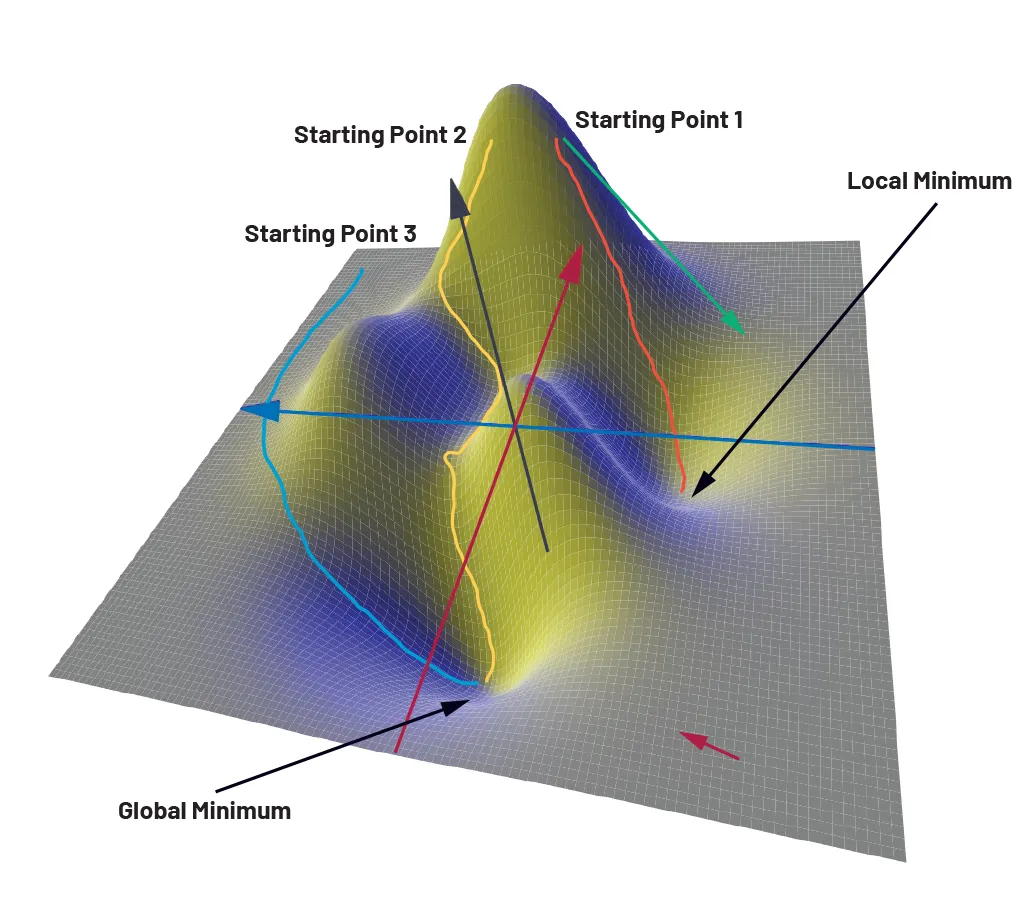</center>
<center>(image credit: <a href = "https://www.embedded.com/training-convolutional-neural-networks/">https://www.embedded.com/training-convolutional-neural-networks/)</a></center>

#### Why are there no nodes?

A node is a point where the wavefunction crosses zero inside the box. Introducing a node forces the function to bend sharply, which increases curvature and therefore increases kinetic energy. Because the minimization procedure seeks the smallest possible energy, any interior node is eliminated. This is why the ground state has no nodes. Excited states, which have higher energy, must contain additional curvature and therefore contain nodes.

#### Connection to analytic solutions

If you compare your numerical result with the exact solution
$$
\psi_1(x)=\sin(\pi x/L),
$$
you should find that they match closely. The important lesson is not that the sine function is the answer, but that the sine function is *the smoothest function allowed by the boundary conditions*. The analytic solution and the numerical solution agree because they are both determined by the same physical principle: minimizing kinetic energy.

#### Why this matters in chemistry

In real molecular systems we usually cannot write down exact wavefunctions. Instead, computational chemistry methods construct approximate functions and improve them by minimizing the energy. The strategy you just used — start with a guess, refine it numerically, and interpret the result physically — is the same strategy used in modern electronic structure calculations.

In other words, what you have just done is a simplified version of how quantum chemistry actually works.

### Question 3
`15 points`

- C4.1: Explain how boundary conditions lead to quantized energies.

a) Why must the ground-state wavefunction contain no interior nodes? Explain your reasoning in terms of both curvature and energy.

b) If you wanted your numerical procedure to find an excited state instead of the ground state, what constraint would you need to impose on the trial function, and why?

c) Real molecular wavefunctions cannot usually be written in closed form. Explain how the numerical procedure you used mirrors how computational chemists determine electronic structures in practice.

<br></br>

## Part 4 - Energy Levels of the Particle in a Box
Now that we have determined which wavefunctions are allowed for this system, we can use them to find the corresponding energy levels.

Recall the time-independent Schrodinger equation within the potential well:
$$ E \psi (x) = -\frac{\hbar{}^2}{2m}\frac{d^2}{dx^2}\psi{}(x) $$

To solve for the energy eigenvalues, recall that the second derivative of a sine function obeys:
$$
\frac{d^2}{dx^2}sin(kx) = -k^2sin(kx)
$$
Since we determined that the eigenfunctions of the energy operator for the particle in a box are of the form $Asin(kx)$, with $k = \frac{n\pi}{L}$, we substitute this into the Schrodinger equation: 
$$
E_n\psi{}_n(x) = -\frac{\hbar{}^2}{2m}(-\frac{\pi^2n^2}{L^2}\psi_n(x))
$$

This yields an equation for the allowed energy levels:
$$
E_n = \frac{\hbar{}^2}{2m}\frac{\pi^2n^2}{L^2} = \frac{h^2n^2}{8mL^2}
$$
Where $n =1,2,3...$ represents the quantum number.

---

### Coding Activity 4
`20 points`

- C4.1: Explain how boundary conditions lead to quantized energies.
- P4.3: Write reusable functions with return values.
- P4.4: Translate equations into code.

Your task is to:
* Create a function which gives the particle in a box energies as a function of n and L, with the units specified.
* Assume $m = m_e$, where $m_e$ is the mass of an electron.
* Use the `pib_energy_plot()` function to explore how E depends on both n and L.

In [2]:
from helper import pib_energy_plot

def pib_energy(n, L_angs=1.5):
    """
    Use atomic units.
    Calculate energy levels for a particle in a 1D box.
    
    Parameters:
        n (int): quantum number, scalar 
        L_angs (float): Length of the box in angstrom, scalar
        
    Returns:
        energy: energy of this PIB wavefunction, scalar
    """
    L_au = L_angs * 1.8889 #conversion between Angstrom and au 
    h_au = 2 * np.pi # Planck's constant (a.u.), how convenient!
    m_electron_au = 1 # The mass of an electron is also quite convenient in atomic units
    energy = #calculate energy here!
    return energy

SyntaxError: invalid syntax (1775045900.py, line 18)

## Question 4
`15 points`

- C4.1: Explain how boundary conditions lead to quantized energies.

a) How does visualizing the energy levels in three dimensions help make sense of the equation? 
b) Based on this plot, predict the shape of the curve when $n = L$? With increasing n, would the energy be increasing, decreasing, or something else? How about if $L = n - 1$?
c) How does the energy of the particle in a box wavefunction depend on the number of nodes in the wavefunction?

## Part 5 - Computational Chemistry
And finally, we arrive at __computational chemistry__! 

With this, we move beyond the simplified models used to build intuition about quantum mechanics and actually simulate molecules with detailed approximations of the Schrodinger equation.

In this section, we will investigate the energy levels of __alkenes__, which share a surprising resemblance to the particle-in-a-box system. One might expect these systems to be analogous just examining their structures—but will the numbers reflect this?

### 5.1 - Specifying molecules with SMILES
Before we can calculate the properties of molecules, we need to be able to specify their structures. While graphical molecular editors exist, we're _power users_, and we prefer to work programmatically. 

Enter __SMILES (Simplified Molecular Input Line Entry System)__. This system allows us to specify molecules using short strings of characters.

Some of the basic rules:
* __Implicit Hydrogens__: Specify only heavy atoms. (methane = `C`)
* __Chains__: Write atoms in order. (ethanol = `CCO`)
* __Bond Order__: Use `=` for double bonds and `#` for triple bonds. (acetylene = `C#C`)
* __Branching__: Use parenthesis to indicate branching. (isopropyl alchol = `CC(C)O`)
* __Rings__: Number ring-forming atoms. (cyclohexane = `C1CCCCC1`)

Try it!

---

## Coding Activity 5
`20 points`

 - P4.1: Distinguish lists vs arrays vs strings and choose correctly.

* Using the create and the structures of the following molecules using SMILES notation, and display them with the `show_molecule()` function:
  1. Benzene
  2. Hexane
  3. 2-Butanol
  4. Butadiene

In [4]:
from helper import show_molecule

ImportError: cannot import name 'show_molecule' from 'helper' (/home/james/pchem-II-lab/particle_in_a_box/helper.py)

## Question 5
`10 points`

a) Why is it useful to represent molecules using SMILES strings? When might this offer an advantage over graphical molecular editors?
b) Give an example of structural information which might not be explicitly defined in a basic SMILES string. 

<br></br>

## 5.2 — Computing Orbital Energies with the Hartree–Fock Method

Now that we can build molecules computationally, we can ask a deeper question: how do we actually determine the quantum states of the electrons in a molecule? In principle, we would solve the Schrödinger equation exactly for all electrons and nuclei. In practice, this is impossible for all but the very smallest systems because electrons interact with each other, and those interactions make the equations mathematically intractable. The Hartree–Fock method is the first systematic approximation chemists developed to overcome this difficulty, and it remains one of the central ideas underlying modern quantum chemistry.

The key idea is to replace the complicated many-electron problem with a simpler one: instead of treating every electron as interacting simultaneously with every other electron, we assume each electron moves in an **average field** created by all the others. This is called a *mean-field approximation*. Rather than solving one enormous equation for all electrons at once, we solve a set of coupled equations for individual orbitals, where each orbital depends on the others.

---

### Conceptual Picture

Imagine trying to describe the motion of many people in a crowded room. Tracking every collision between every pair would be nearly impossible. A simpler approach is to assume each person moves through an average crowd density that represents everyone else. Hartree–Fock does something similar for electrons: each electron feels an effective potential instead of tracking every instantaneous interaction.

---

### The Hartree–Fock Wavefunction

In quantum mechanics, the full state of an $N$-electron system is described by a wavefunction depending on all electron coordinates. Hartree–Fock approximates this complicated object using a special structure called a **Slater determinant**, built from single-electron orbitals $\psi_i(r)$. This construction automatically enforces the Pauli exclusion principle, which requires that exchanging two electrons changes the sign of the wavefunction.

The orbitals are not known ahead of time. They must be determined so that the total electronic energy is as small as possible.

---

### The Hartree–Fock Equations

Each orbital satisfies an equation that looks similar to the single-particle Schrödinger equation,

$$E_{HF}\psi_i(r) = -\frac{\hbar{}^2}{2m}\nabla^2\psi_i(r) + V_{nuclear}\psi_i(r) + V_{electronic}(r)\psi_i(r) + V_{exchange}(r)\psi_i(r)$$

    * $\psi_i(r)$ is the wavefunction of the $i$_th_ orbital as a function of $r = (x,y,z)$.
    * The first term represents __kinetic energy__.
    * $V_{nuclear}$ represents __electron-nucleus attraction__.
    * $V_{electronic}$ represents __electron-electron repulsion__.
    * $V_{exchange}$ accounts for the __Pauli Exclusion Principle__.

Unlike the simple Hamiltonian of a one-electron system, the Fock operator depends on the orbitals themselves. This means the equations cannot be solved directly in one step. Instead, we must solve them iteratively.

---

### Why a Basis Set Is Needed

Orbitals are functions of position, which means in principle they contain infinitely many degrees of freedom. To make computation possible, we restrict the orbitals to be built from a finite collection of known functions called a **basis set**. Each molecular orbital is expressed as a linear combination of basis functions:

$$
\psi_i = \sum_j c_{ij}\,\chi_j.
$$

The coefficients $c_{ij}$ are the quantities the algorithm actually determines. A larger basis set gives more flexibility and potentially higher accuracy, but it also increases computational cost.

---

### The Self-Consistent Field Procedure

Because the effective potential depends on the orbitals and the orbitals depend on the potential, the solution must be found through iteration. The Hartree–Fock procedure therefore follows a cycle:

1. **Initial guess**  
   Start with approximate orbitals, often constructed from atomic orbitals.

2. **Build effective operator**  
   Use those orbitals to construct the Fock operator.

3. **Solve orbital equations**  
   Compute a new set of orbitals from that operator.

4. **Update and repeat**  
   Compare the new orbitals with the old ones and repeat the process until they stop changing.

This is why Hartree–Fock is often called the **Self-Consistent Field (SCF)** method: the orbitals must be consistent with the field they themselves generate.

---

### Convergence

The iteration continues until changes in the energy or orbitals fall below a chosen threshold. At that point, the calculation is said to have **converged**, meaning the algorithm has reached a stable solution. This final set of orbitals represents the best approximation to the molecular electronic structure within the Hartree–Fock framework.

---

### What Hartree–Fock Gets Right — and What It Misses

Hartree–Fock captures several essential physical features:

- antisymmetry of the wavefunction  
- Pauli exclusion principle  
- qualitative orbital structure  
- trends in molecular bonding  

However, it does **not** fully account for correlated electron motion. Real electrons avoid each other more effectively than the mean-field model predicts, so Hartree–Fock energies are usually too high. More advanced quantum chemistry methods improve on Hartree–Fock by adding corrections for this missing *electron correlation*, but nearly all of them start from a Hartree–Fock calculation.

---

### Why We Use It

Even though it is an approximation, Hartree–Fock is extremely important because it:

- provides a practical starting point for more accurate methods  
- gives physically meaningful orbitals  
- scales reasonably with system size  
- illustrates how quantum mechanical structure emerges from energy minimization  

In this section, we will use the quantum chemistry software package `Psi4` to perform a Hartree–Fock calculation and examine the resulting orbital energies for a conjugated molecule. By doing so, you will see how a modern computational chemistry program implements the same principles you have already explored in simplified form: constructing trial functions, minimizing energy, and interpreting the resulting quantum states.

---

## Coding Activity 6
`15 points`

 - C4.2: Relate conjugation length to absorption wavelength.
 - P4.3: Write reusable functions with return values.
 - P4.4: Translate equations into code.

Your task is to:
* Complete the missing parts of the `quantum_energy_gap()` and `pib_energy_gap()` functions.
* Use the `get_gaps()` function to obtain HOMO-LUMO gaps for all alkenes from 2 to 18 carbons long.
* Plot the resulting energy gaps for each model using the provided code.

In [5]:
octatetraene = #create the molecule!
psi4_mol = #use the function to convert between formats!
psi4.set_output_file('output.dat',False)
psi4.set_memory('1 GB')
my_theory = 'SCF/STO-3G'

energy, wfn = psi4.energy(my_theory,return_wfn=True,molecule=psi4_mol)

SyntaxError: invalid syntax (1232404386.py, line 1)

In [ ]:
## Question 6
a) How are the Hartree Fock equations similar to the examples you have seen for the Schrodinger Equation? How are they different?
b) Why might there be differences between the energy levels of the orbitals and those of the particle in a box?
c) Is there a range for which the orbital energies have a similar shape to the particle in a box energies?